## Marketing Customer Analytics 

---
### Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

---
### Loading & Inspecting Dataset

In [3]:
df = pd.read_csv('OnlineRetail.csv', encoding='latin1')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [4]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [5]:
# Re-ordering the features
df = df[['CustomerID' , 'InvoiceNo', 'StockCode','Description','Quantity','UnitPrice'
         ,'Country','InvoiceDate']]

In [6]:
df = df[df['Country'] != 'Israel']

In [7]:
df.sample(5)

,CustomerID,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country,InvoiceDate
191541,14911.0,553375,21673,WHITE SPOT BLUE CERAMIC DRAWER KNOB,24,1.25,EIRE,5/16/2011 14:53
327501,15271.0,565674,23234,BISCUIT TIN VINTAGE CHRISTMAS,6,2.89,United Kingdom,9/6/2011 9:49
399509,14088.0,571281,23085,ANTIQUE SILVER BAUBLE LAMP,12,8.25,United Kingdom,10/16/2011 13:23
500651,16210.0,578793,23558,LANDMARK FRAME LONDON BRIDGE,3,12.50,United Kingdom,11/25/2011 12:21
305213,15615.0,563656,23014,GLASS APOTHECARY BOTTLE ELIXIR,4,3.95,United Kingdom,8/18/2011 10:48


In [8]:
df.info()

<class 'pandas.DataFrame'>
Index: 541612 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CustomerID   406579 non-null  float64
 1   InvoiceNo    541612 non-null  str    
 2   StockCode    541612 non-null  str    
 3   Description  540158 non-null  str    
 4   Quantity     541612 non-null  int64  
 5   UnitPrice    541612 non-null  float64
 6   Country      541612 non-null  str    
 7   InvoiceDate  541612 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 71.6 MB


In [9]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
CustomerID,406579.0,15289.31,1712.88,12346.00,13956.00,15152.00,16791.00,18287.0
Quantity,541612.0,9.55,218.14,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541612.0,4.61,96.79,-11062.06,1.25,2.08,4.13,38970.0


In [10]:
df.shape

(541612, 8)

---
### Data Preprocessing & Feature Extraction
- **Missing Values**
- **Duplication**
- **Invalid Values**
- **Outliers**
- **Data Manipulation**
- **Feature Extraction**


In [11]:
# Missing Values
df.isna().sum()

CustomerID     135033
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
UnitPrice           0
Country             0
InvoiceDate         0
dtype: int64

In [12]:
df.dropna(inplace= True)

In [13]:
# Duplication
df.duplicated().sum()

np.int64(5222)

In [14]:
df.drop_duplicates(inplace= True)

In [15]:
df.shape

(401357, 8)

- **To get the invalid values**

In [16]:
## Quantity
df['Quantity'].describe().round(2).T

count    401357.00
mean         12.18
std         250.36
min      -80995.00
25%           2.00
50%           5.00
75%          12.00
max       80995.00
Name: Quantity, dtype: float64

In [17]:
# remove the invalid values in the quantity feature.
df = df[df['Quantity'] > 0 ]

In [18]:
df['UnitPrice'].describe().round(2).T

count    392487.00
mean          3.13
std          22.25
min           0.00
25%           1.25
50%           1.95
75%           3.75
max        8142.75
Name: UnitPrice, dtype: float64

In [19]:
df = df[df['UnitPrice'] > 0]

In [20]:
df.shape

(392447, 8)

- **Outliers**

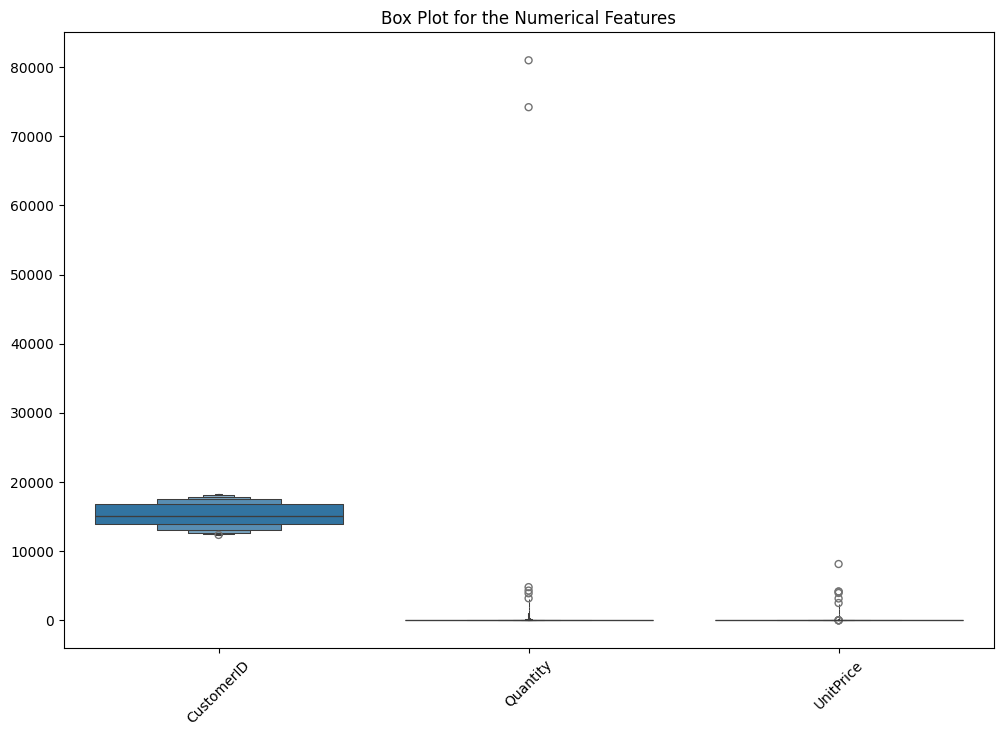

In [21]:
plt.figure(figsize=(12,8))
plt.xticks(rotation = 45)
sns.boxenplot(df)
plt.title("Box Plot for the Numerical Features")
plt.show()

In [22]:
q1 = df['Quantity'].quantile(0.25)
q3 = df['Quantity'].quantile(0.75)

IQR = q3 - q1

lowre_margin = q1 - 1.5 * IQR
upper_margin = q3 + 1.5 * IQR

print(f'the length of the dataframe Before remove outliers: {len(df)}')
df = df[(df['Quantity'] >= lowre_margin) & (df['Quantity'] <= upper_margin)]
print(f'the length of the dataframe after remove outliers: {len(df)}')


the length of the dataframe Before remove outliers: 392447
the length of the dataframe after remove outliers: 366861


<Axes: ylabel='Quantity'>

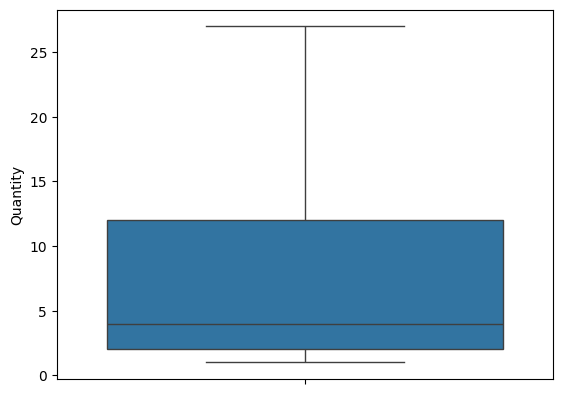

In [23]:
sns.boxplot(df['Quantity'])

In [24]:
q1 = df['UnitPrice'].quantile(0.25)
q3 = df['UnitPrice'].quantile(0.75)

IQR = q3 - q1

lowre_margin = q1 - 1.5 * IQR
upper_margin = q3 + 1.5 * IQR

print(f'the length of the dataframe Before remove outliers: {len(df)}')

df = df[(df['UnitPrice'] >= lowre_margin) & (df['UnitPrice'] <= upper_margin)]

print(f'the length of the dataframe after remove outliers: {len(df)}')


the length of the dataframe Before remove outliers: 366861
the length of the dataframe after remove outliers: 333045


- **Data Mainpulation**

In [25]:
df['InvoiceDate']

0          12/1/2010 8:26
1          12/1/2010 8:26
2          12/1/2010 8:26
3          12/1/2010 8:26
4          12/1/2010 8:26
               ...       
541904    12/9/2011 12:50
541905    12/9/2011 12:50
541906    12/9/2011 12:50
541907    12/9/2011 12:50
541908    12/9/2011 12:50
Name: InvoiceDate, Length: 333045, dtype: str

In [26]:
df['InvoiceDate'].info()

<class 'pandas.Series'>
Index: 333045 entries, 0 to 541908
Series name: InvoiceDate
Non-Null Count   Dtype
--------------   -----
333045 non-null  str  
dtypes: str(1)
memory usage: 9.9 MB


In [27]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']).dt.date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [28]:
df['InvoiceDate'].info()


<class 'pandas.Series'>
Index: 333045 entries, 0 to 541908
Series name: InvoiceDate
Non-Null Count   Dtype        
--------------   -----        
333045 non-null  datetime64[s]
dtypes: datetime64[s](1)
memory usage: 5.1 MB


In [29]:
df['InvoiceDate']


0        2010-12-01
1        2010-12-01
2        2010-12-01
3        2010-12-01
4        2010-12-01
            ...    
541904   2011-12-09
541905   2011-12-09
541906   2011-12-09
541907   2011-12-09
541908   2011-12-09
Name: InvoiceDate, Length: 333045, dtype: datetime64[s]

In [30]:
df['Year'] = df['InvoiceDate'].dt.year
df['Quarter'] = df['InvoiceDate'].dt.quarter
df['MonthName'] = df['InvoiceDate'].dt.month_name()
df['DayName'] = df['InvoiceDate'].dt.day_name()

In [31]:
df.sample(5)

,CustomerID,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country,InvoiceDate,Year,Quarter,MonthName,DayName
290561,16873.0,562381,20725,LUNCH BAG RED RETROSPOT,10,1.65,United Kingdom,2011-08-04,2011,3,August,Thursday
498228,16885.0,578515,23300,GARDENERS KNEELING PAD CUP OF TEA,1,1.65,United Kingdom,2011-11-24,2011,4,November,Thursday
140594,15856.0,548450,22983,CARD BILLBOARD FONT,12,0.42,United Kingdom,2011-03-31,2011,1,March,Thursday
386246,15756.0,570229,20711,JUMBO BAG TOYS,2,2.08,United Kingdom,2011-10-09,2011,4,October,Sunday
266712,17863.0,560265,22986,WRAP GINGHAM ROSE,25,0.42,United Kingdom,2011-07-17,2011,3,July,Sunday


In [32]:
df.tail()

,CustomerID,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country,InvoiceDate,Year,Quarter,MonthName,DayName
541904,12680.0,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,0.85,France,2011-12-09,2011,4,December,Friday
541905,12680.0,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,France,2011-12-09,2011,4,December,Friday
541906,12680.0,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,France,2011-12-09,2011,4,December,Friday
541907,12680.0,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,France,2011-12-09,2011,4,December,Friday
541908,12680.0,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,4.95,France,2011-12-09,2011,4,December,Friday


In [33]:
df.reset_index(inplace= True)

In [34]:
df.tail()

,index,CustomerID,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country,InvoiceDate,Year,Quarter,MonthName,DayName
333040,541904,12680.0,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,0.85,France,2011-12-09,2011,4,December,Friday
333041,541905,12680.0,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,France,2011-12-09,2011,4,December,Friday
333042,541906,12680.0,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,France,2011-12-09,2011,4,December,Friday
333043,541907,12680.0,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,France,2011-12-09,2011,4,December,Friday
333044,541908,12680.0,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,4.95,France,2011-12-09,2011,4,December,Friday


In [35]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [40]:
df.head(2)

,index,CustomerID,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country,InvoiceDate,Year,Quarter,MonthName,DayName,TotalPrice
0,0,17850.0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,United Kingdom,2010-12-01,2010,4,December,Wednesday,15.30
1,1,17850.0,536365,71053,WHITE METAL LANTERN,6,3.39,United Kingdom,2010-12-01,2010,4,December,Wednesday,20.34


In [41]:
df.drop(columns={'index'} , inplace= True)

In [42]:
df['Description']

0          WHITE HANGING HEART T-LIGHT HOLDER
1                         WHITE METAL LANTERN
2              CREAM CUPID HEARTS COAT HANGER
3         KNITTED UNION FLAG HOT WATER BOTTLE
4              RED WOOLLY HOTTIE WHITE HEART.
                         ...                 
333040            PACK OF 20 SPACEBOY NAPKINS
333041           CHILDREN'S APRON DOLLY GIRL 
333042          CHILDRENS CUTLERY DOLLY GIRL 
333043        CHILDRENS CUTLERY CIRCUS PARADE
333044          BAKING SET 9 PIECE RETROSPOT 
Name: Description, Length: 333045, dtype: str

In [43]:
df['Description'] = df['Description'].str.title()

In [44]:
df.shape

(333045, 13)

---
## Exploratory Data Analysis

In [45]:
df.head()

,CustomerID,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country,InvoiceDate,Year,Quarter,MonthName,DayName,TotalPrice
0,17850.0,536365,85123A,White Hanging Heart T-Light Holder,6,2.55,United Kingdom,2010-12-01,2010,4,December,Wednesday,15.30
1,17850.0,536365,71053,White Metal Lantern,6,3.39,United Kingdom,2010-12-01,2010,4,December,Wednesday,20.34
2,17850.0,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2.75,United Kingdom,2010-12-01,2010,4,December,Wednesday,22.00
3,17850.0,536365,84029G,Knitted Union Flag Hot Water Bottle,6,3.39,United Kingdom,2010-12-01,2010,4,December,Wednesday,20.34
4,17850.0,536365,84029E,Red Woolly Hottie White Heart.,6,3.39,United Kingdom,2010-12-01,2010,4,December,Wednesday,20.34



#### Country
- **Uni-Variant Analysis**
- **Bi-Variant Analysis**
- **Multi-Variant Analysis**


- **Uni-Variant Analysis**

In [47]:
df['Country'].describe(include='O') # Overview

count             333045
unique                36
top       United Kingdom
freq              300281
Name: Country, dtype: object

In [48]:
df['Country'].value_counts()

Country
United Kingdom          300281
Germany                   7448
France                    6890
EIRE                      5443
Spain                     2040
Belgium                   1660
Switzerland               1433
Portugal                  1252
Norway                     772
Netherlands                617
Italy                      604
Channel Islands            546
Finland                    518
Australia                  510
Cyprus                     475
Austria                    343
Denmark                    297
Poland                     253
Sweden                     249
Unspecified                210
Iceland                    166
USA                        160
Singapore                  151
Canada                     126
Greece                     125
Japan                      110
Malta                       91
United Arab Emirates        58
European Community          47
RSA                         45
Lebanon                     33
Lithuania                   29


In [49]:
round((df['Country'].value_counts() / len(df))*100 , 3)

Country
United Kingdom          90.162
Germany                  2.236
France                   2.069
EIRE                     1.634
Spain                    0.613
Belgium                  0.498
Switzerland              0.430
Portugal                 0.376
Norway                   0.232
Netherlands              0.185
Italy                    0.181
Channel Islands          0.164
Finland                  0.156
Australia                0.153
Cyprus                   0.143
Austria                  0.103
Denmark                  0.089
Poland                   0.076
Sweden                   0.075
Unspecified              0.063
Iceland                  0.050
USA                      0.048
Singapore                0.045
Canada                   0.038
Greece                   0.038
Japan                    0.033
Malta                    0.027
United Arab Emirates     0.017
European Community       0.014
RSA                      0.014
Lebanon                  0.010
Lithuania                0.009


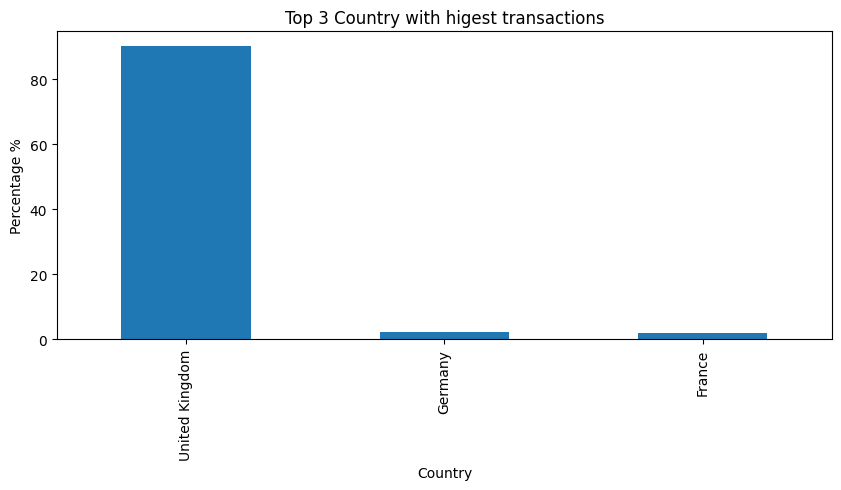

In [50]:
plt.figure(figsize=(10,4))
round((df['Country'].value_counts() / len(df))*100 , 3).head(3).plot(kind='bar')
plt.title('Top 3 Country with higest transactions')
plt.ylabel('Percentage %')
plt.show()

- **Bi-Variant Analysis**

In [51]:
df.sample(2)

,CustomerID,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country,InvoiceDate,Year,Quarter,MonthName,DayName,TotalPrice
331347,14653.0,581402,79160,Heart Shape Wireless Doorbell,1,2.10,United Kingdom,2011-12-08,2011,4,December,Thursday,2.1
241111,15113.0,571289,21481,Fawn Blue Hot Water Bottle,18,3.75,United Kingdom,2011-10-16,2011,4,October,Sunday,67.5


In [52]:
df.groupby('Country')['TotalPrice'].sum().round(3).sort_values(ascending= False).head()

Country
United Kingdom    3680989.464
Germany            137946.330
France             121978.940
EIRE               105899.620
Spain               29826.960
Name: TotalPrice, dtype: float64

In [53]:
df_grouped = df.groupby('Country')['TotalPrice'].sum().round(3).sort_values(ascending= False).head().reset_index()

px.bar(
    data_frame= df_grouped,
    x= 'Country',
    y= 'TotalPrice',
    title= 'Top 5 Country that has most total price'
)

In [54]:
df_grouped = df.groupby('Country')['TotalPrice'].mean().round(3).sort_values(ascending= False).head().reset_index()

px.bar(
    data_frame= df_grouped,
    x= 'Country',
    y= 'TotalPrice',
    title= 'Top 5 Country that has most efficiency for the total price',
    text_auto=True
)

In [55]:
df.groupby('Country')['Quantity'].mean().sort_values(ascending= False)

Country
Czech Republic          20.111111
Denmark                 15.060606
Lithuania               14.827586
Singapore               13.370861
Brazil                  13.120000
Sweden                  13.016064
United Arab Emirates    12.637931
Switzerland             12.551989
Canada                  12.206349
Norway                  12.165803
USA                     11.837500
Channel Islands         11.752747
Netherlands             11.682334
Finland                 11.517375
Iceland                 11.403614
Germany                 11.260607
Poland                  11.138340
France                  10.936575
EIRE                    10.795333
Belgium                 10.694578
Austria                 10.655977
Greece                  10.648000
Italy                   10.438742
Australia               10.221569
European Community      10.063830
Lebanon                  9.757576
Portugal                 9.615815
Japan                    9.072727
Spain                    9.023529
Malta 

In [56]:
df.sample(2)

,CustomerID,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country,InvoiceDate,Year,Quarter,MonthName,DayName,TotalPrice
150747,18245.0,559909,22706,Wrap Cowboys,25,0.42,United Kingdom,2011-07-13,2011,3,July,Wednesday,10.50
284924,14382.0,576076,23293,Set Of 12 Fairy Cake Baking Cases,1,0.83,United Kingdom,2011-11-13,2011,4,November,Sunday,0.83


In [57]:
df.groupby(['Country' , 'Description'])['TotalPrice'].sum().sort_values(ascending= False)

Country         Description                       
United Kingdom  Party Bunting                         32456.400
                White Hanging Heart T-Light Holder    29905.260
                Jumbo Bag Red Retrospot               21991.090
                Assorted Colour Bird Ornament         21961.550
                Spotty Bunting                        21038.050
                                                        ...    
Spain           French Style Storage Jar Cafe             0.290
                Small Yellow Babushka Notebook            0.210
Unspecified     Retro Pill Box Key Chain,The King         0.190
United Kingdom  Pads To Match All Cushions                0.003
                Bank Charges                              0.001
Name: TotalPrice, Length: 16059, dtype: float64

In [58]:
df_grouped = df.groupby(['Country' , 'Description'])['TotalPrice'].sum().sort_values(ascending= False).head(5).reset_index()

px.bar(
    data_frame= df_grouped,
    x= 'Country',
    y= 'TotalPrice',
    color= 'Description',
    title= 'Top 5 Description that has total price, Regarding Country',
    barmode='group',
    text_auto=True
)


#### Description
- **Uni-Variant Analysis**
- **Bi-Variant Analysis**
- **Multi-Variant Analysis**


- **Uni-Variant Analysis**

In [59]:
df['Description'].describe(include= 'O')

count                                 333045
unique                                  3575
top       White Hanging Heart T-Light Holder
freq                                    1667
Name: Description, dtype: object

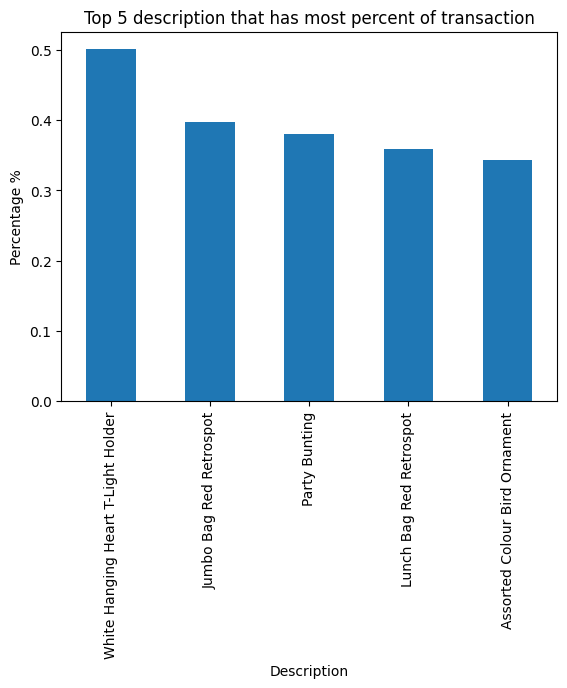

In [60]:
round((df['Description'].value_counts() / len(df)) * 100,3).head().plot(kind='bar')
plt.title("Top 5 description that has most percent of transaction")
plt.ylabel("Percentage %")
plt.show()

- **Bi-Variant Analysis**

In [61]:
df.sample(3)

,CustomerID,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country,InvoiceDate,Year,Quarter,MonthName,DayName,TotalPrice
227244,17419.0,569726,22189,Cream Heart Card Holder,8,3.95,United Kingdom,2011-10-06,2011,4,October,Thursday,31.6
179187,16407.0,563920,23032,Drawer Knob Crackle Glaze Ivory,12,1.65,United Kingdom,2011-08-21,2011,3,August,Sunday,19.8
126756,14241.0,556186,47566,Party Bunting,4,4.95,United Kingdom,2011-06-09,2011,2,June,Thursday,19.8


In [62]:
df.groupby('Description')['TotalPrice'].sum().sort_values(ascending= False).head()

Description
Party Bunting                         34947.90
White Hanging Heart T-Light Holder    31760.81
Jumbo Bag Red Retrospot               24923.50
Spotty Bunting                        23498.20
Assorted Colour Bird Ornament         22940.06
Name: TotalPrice, dtype: float64

In [63]:
df.groupby('Description')['TotalPrice'].mean().sort_values(ascending= False).head()


Description
Small Deco Jewellery Stand          178.8
3 Hook Photo Shelf Antique White    156.9
Recycled Acapulco Mat Turquoise     149.0
Recycled Acapulco Mat Red           149.0
Tall Rococo Candle Holder           130.5
Name: TotalPrice, dtype: float64

---
## Time Series Analysis

In [64]:
df.set_index(df['InvoiceDate'],inplace= True)

In [65]:
df.head()

,CustomerID,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country,InvoiceDate,Year,Quarter,MonthName,DayName,TotalPrice
InvoiceDate,,,,,,,,,,,,,
2010-12-01,17850.0,536365,85123A,White Hanging Heart T-Light Holder,6,2.55,United Kingdom,2010-12-01,2010,4,December,Wednesday,15.30
2010-12-01,17850.0,536365,71053,White Metal Lantern,6,3.39,United Kingdom,2010-12-01,2010,4,December,Wednesday,20.34
2010-12-01,17850.0,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2.75,United Kingdom,2010-12-01,2010,4,December,Wednesday,22.00
2010-12-01,17850.0,536365,84029G,Knitted Union Flag Hot Water Bottle,6,3.39,United Kingdom,2010-12-01,2010,4,December,Wednesday,20.34
2010-12-01,17850.0,536365,84029E,Red Woolly Hottie White Heart.,6,3.39,United Kingdom,2010-12-01,2010,4,December,Wednesday,20.34


In [66]:
df.resample("YE").agg(
    totalPrice = ('TotalPrice' , 'sum'),
    totalQuantity = ('Quantity' , 'sum')
)

,totalPrice,totalQuantity
InvoiceDate,,
2010-12-31,284122.150,149998
2011-12-31,4011706.954,2363720


In [67]:
df.resample('MS').agg(
    TotalPrice = ('TotalPrice' , 'sum'),
    TotalQuantity = ('Quantity' , 'sum')
)

,TotalPrice,TotalQuantity
InvoiceDate,,
2010-12-01,284122.150,149998
2011-01-01,232767.980,135676
2011-02-01,219010.180,126793
2011-03-01,285458.420,169486
2011-04-01,242420.681,146710
2011-05-01,324899.440,184770
2011-06-01,290158.850,171859
2011-07-01,288498.881,179665
2011-08-01,302463.800,185558


#### =Total Price

In [68]:
df.resample('YE')['TotalPrice'].sum()

InvoiceDate
2010-12-31     284122.150
2011-12-31    4011706.954
Freq: YE-DEC, Name: TotalPrice, dtype: float64

#### What is the total unit price for each year?

In [69]:
df.sample()

,CustomerID,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country,InvoiceDate,Year,Quarter,MonthName,DayName,TotalPrice
InvoiceDate,,,,,,,,,,,,,
2011-10-05,14730.0,569669,22277,Cosmetic Bag Vintage Rose Paisley,1,2.1,United Kingdom,2011-10-05,2011,4,October,Wednesday,2.1


In [70]:
df.resample("ME")['TotalPrice'].sum()

InvoiceDate
2010-12-31    284122.150
2011-01-31    232767.980
2011-02-28    219010.180
2011-03-31    285458.420
2011-04-30    242420.681
2011-05-31    324899.440
2011-06-30    290158.850
2011-07-31    288498.881
2011-08-31    302463.800
2011-09-30    480898.852
2011-10-31    524719.240
2011-11-30    642984.880
2011-12-31    177425.750
Freq: ME, Name: TotalPrice, dtype: float64

In [71]:
df_grouped = df.resample("ME")['TotalPrice'].sum().reset_index()

px.line(
    data_frame= df_grouped,
    x= 'InvoiceDate',
    y= 'TotalPrice',
    title= 'Monthly Total Price Over Time',
    labels={
        'InvoiceDate' : 'Date',
        'TotalPrice' : 'Total Price $'
    },
    markers= True,
    line_shape= 'spline'
)


In [72]:
df.sample(2)

,CustomerID,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country,InvoiceDate,Year,Quarter,MonthName,DayName,TotalPrice
InvoiceDate,,,,,,,,,,,,,
2011-02-28,16057.0,545081,21210,Set Of 72 Retrospot Paper Doilies,12,1.45,United Kingdom,2011-02-28,2011,1,February,Monday,17.4
2010-12-07,16904.0,537614,22866,Hand Warmer Scotty Dog Design,8,2.10,United Kingdom,2010-12-07,2010,4,December,Tuesday,16.8


Text(0.5, 1.0, 'Total Price vs. Quantity')

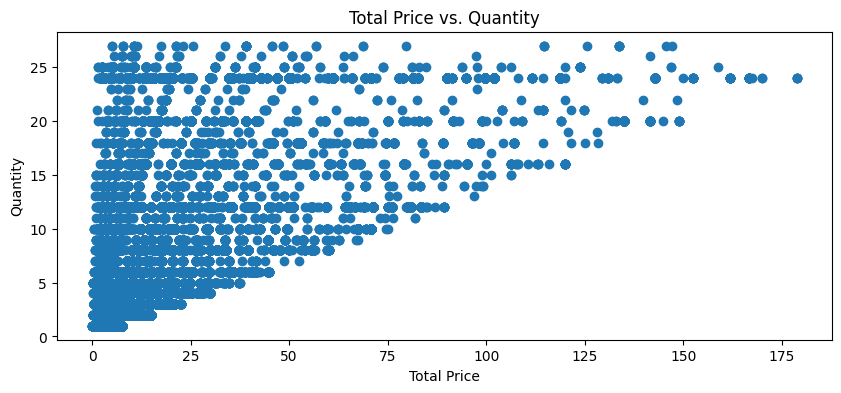

In [73]:
plt.figure(figsize=(10,4))
plt.scatter(x=df['TotalPrice'] , y=df['Quantity'])
plt.xlabel('Total Price')
plt.ylabel('Quantity')
plt.title('Total Price vs. Quantity')

Text(0.5, 1.0, 'Total Price vs. Unit Price')

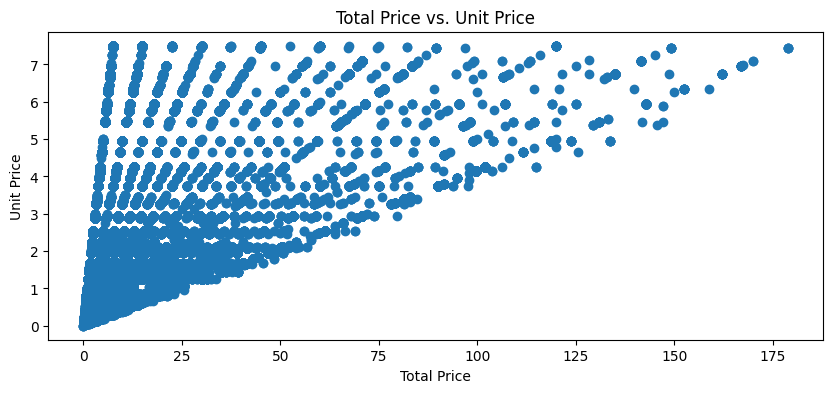

In [74]:
plt.figure(figsize=(10,4))
plt.scatter(x=df['TotalPrice'] , y=df['UnitPrice'])
plt.xlabel('Total Price')
plt.ylabel('Unit Price')
plt.title('Total Price vs. Unit Price')

In [75]:
df.sample(2)

,CustomerID,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country,InvoiceDate,Year,Quarter,MonthName,DayName,TotalPrice
InvoiceDate,,,,,,,,,,,,,
2011-09-25,16049.0,568188,21791,Vintage Heads And Tails Card Game,2,1.25,United Kingdom,2011-09-25,2011,3,September,Sunday,2.5
2011-03-28,14755.0,547883,47566,Party Bunting,8,4.95,United Kingdom,2011-03-28,2011,1,March,Monday,39.6


<Axes: >

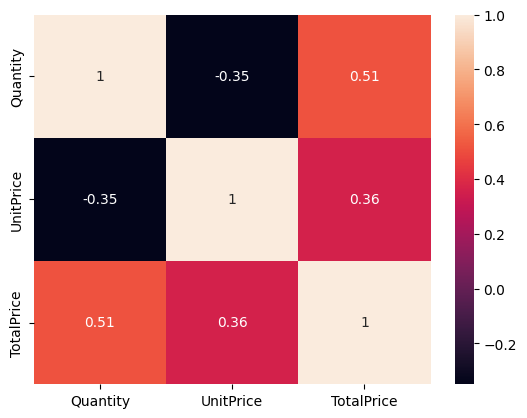

In [76]:
numerical_col = df[['Quantity' , 'UnitPrice' , 'TotalPrice']]
corr_matrix = numerical_col.corr()

sns.heatmap(corr_matrix , annot= True)


In [77]:
df_grouped = df.resample('ME')['TotalPrice'].sum().reset_index()

px.line(
    data_frame=df_grouped,
    x = 'InvoiceDate',
    y = 'TotalPrice',
    labels={
        'InvoiceDate' : 'Date',
        'TotalPrice' : 'Total Price ($)'
    },
    title='Monthly total profit over time',
    markers=True,
    line_shape = 'spline'
)

In [78]:
df_grouped = df.resample("ME")['TotalPrice'].sum().reset_index()

px.line(
    data_frame= df_grouped,
    x= 'InvoiceDate',
    y= 'TotalPrice',
    labels={
        'InvoiceDate' : 'Date',
        'TotalPrice' : 'Total Price $'
    },
    title= 'Monthly Total Profit Over Time',
    markers= True,
    line_shape='spline'
)

---
## RFM Analysis

In [79]:
rfm

,Recency,Frequency,Monetary,AvgOrderValue,CustomerLifetime
CustomerID,,,,,
12347.0,2,7,3314.73,473.532857,365
12348.0,248,3,90.20,30.066667,110
12349.0,18,1,999.15,999.150000,0
12350.0,310,1,294.40,294.400000,0
12352.0,36,7,1130.94,161.562857,260
...,...,...,...,...,...
18280.0,277,1,137.00,137.000000,0
18281.0,180,1,46.92,46.920000,0
18282.0,7,2,113.13,56.565000,119


---
Save the dataset

In [80]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 333045 entries, 2010-12-01 to 2011-12-09
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype        
---  ------       --------------   -----        
 0   CustomerID   333045 non-null  float64      
 1   InvoiceNo    333045 non-null  str          
 2   StockCode    333045 non-null  str          
 3   Description  333045 non-null  str          
 4   Quantity     333045 non-null  int64        
 5   UnitPrice    333045 non-null  float64      
 6   Country      333045 non-null  str          
 7   InvoiceDate  333045 non-null  datetime64[s]
 8   Year         333045 non-null  int32        
 9   Quarter      333045 non-null  int32        
 10  MonthName    333045 non-null  str          
 11  DayName      333045 non-null  str          
 12  TotalPrice   333045 non-null  float64      
dtypes: datetime64[s](1), float64(3), int32(2), int64(1), str(6)
memory usage: 53.8 MB


In [82]:
df.to_csv('OnlineRetail_Cleaned.csv')